# Chapter 4 — Framework 1: Cluster-ending taxa poles and site-level taxa matrices



This notebook follows the same chapter-style narrative structure used in Chapter 3 Framework 3 so the analytical workflow can be read from top to bottom while reusable implementation details stay isolated in a Definition Corner.



The execution structure is:



```text

Inputs → Analysis parameters → Definition Corner → Process → Outputs → Visualization

```



The workflow loads the A1 contamination-score artifact together with the A5 and A6 cluster-projection artifacts, constructs cluster-specific ending subsets, summarizes their pole descriptors, materializes the corresponding cluster taxa matrices, and then visualizes the ending-pole taxa composition.


# Inputs

In [76]:
from pathlib import Path
import pandas as pd

STUDY_CASE = "corridor"
SITE_ID_COLUMN = "Integrated Code"

if STUDY_CASE == "DR":
    STUDY_CASE_LABEL = "Detroit River case study"
    CASE_ROOT_DIR = Path("../DetroitRiverCase")
else:
    STUDY_CASE_LABEL = "Corridor case study"
    CASE_ROOT_DIR = Path("..")

METADATA_DIR = CASE_ROOT_DIR / "data"
ARTIFACT_DIR = CASE_ROOT_DIR / "artifacts"
RESULTS_DIR = CASE_ROOT_DIR / "results"
FIGURE_DIR = CASE_ROOT_DIR / "figures"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Load site sample information
site_info = pd.read_excel(METADATA_DIR / "Info.xlsx")
site_ids = site_info[SITE_ID_COLUMN].reset_index(drop=True).rename(SITE_ID_COLUMN)

# Load the taxa matrix T and merge with site IDs
T = pd.read_excel(METADATA_DIR / "T.xlsx").reset_index(drop=True)
T_with_site_id = pd.concat([site_ids, T], axis=1)

# Load the A1 stressor-score matrix S_c
A1 = pd.read_excel(ARTIFACT_DIR / "A1_stressors_and_scores.xlsx").reset_index(drop=True)

# Load the artifact A5 - all sites cluster C1 projections
A5 = pd.read_excel(ARTIFACT_DIR / "A5_all_sites_cluster_C1.xlsx").reset_index(drop=True)
# Load the artifact A6 - all sites cluster C2 projections
A6 = pd.read_excel(ARTIFACT_DIR / "A6_all_sites_cluster_C2.xlsx").reset_index(drop=True)
# Load cluster C3 projections if it's DR case
if STUDY_CASE == "DR":
    A7 = pd.read_excel(ARTIFACT_DIR / "A7_all_sites_cluster_C3.xlsx").reset_index(drop=True)

print(f"Study case: {STUDY_CASE_LABEL}")
print(f"Loaded taxa matrix T: {T_with_site_id.shape[0]} sites x {T_with_site_id.shape[1] - 1} taxa variables")
display(T_with_site_id.head())
print(f"Loaded A1 stressor-score matrix: {A1.shape[0]} sites x {A1.shape[1] - 1} variables")
display(A1.head())
print(f"Loaded A5 all sites cluster C1 projections: {A5.shape[0]} sites x {A5.shape[1] - 1} variables")
display(A5.head())
print(f"Loaded A6 all sites cluster C2 projections: {A6.shape[0]} sites x {A6.shape[1] - 1} variables")
display(A6.head())
if STUDY_CASE == "DR":
    print(f"Loaded A7 all sites cluster C3 projections: {A7.shape[0]} sites x {A7.shape[1] - 1} variables")
    display(A7.head())

Study case: Corridor case study
Loaded taxa matrix T: 310 sites x 16 taxa variables


,Integrated Code,Oligochaeta,Nematoda,Chironomidae,Ceratopogonidae,Hexagenia,Caenis,Hydropsychidae,Other Trichoptera,Amphipoda,Dreissena,Acari,Hydrozoa,Hirudinea,Turbellaria,Gastropoda,Sphaeriidae
0,DR-02,2.269984,0.563546,1.655598,0.0,0.309116,0.000000,2.438439,0.0,4.529993,6.082918,0.000000,0.00000,0.00000,0.0,0.000000,0.0
1,DR-03,3.808504,3.512091,6.242625,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.801982,0.801982,0.00000,0.00000,0.0,0.456015,0.0
2,DR-04,4.820163,5.519382,4.733464,0.0,0.815949,0.000000,0.000000,0.0,0.000000,0.172158,1.010022,0.00000,0.00000,0.0,0.464907,0.0
3,DR-06,1.449187,0.181596,2.271083,0.0,0.999573,0.033941,0.000000,0.0,1.840242,6.475708,0.000000,1.82093,0.23027,0.0,0.000000,0.0
4,DR-07,1.082238,0.246371,2.499653,0.0,0.128438,0.000000,0.128438,0.0,4.224262,6.266368,0.000000,0.00000,0.00000,0.0,0.246371,0.0


Loaded A1 stressor-score matrix: 310 sites x 7 variables


,Integrated Code,PC1,PC2,PC3,PC4,PC5,SumRel,MaxRel
0,DR-02,-3.551586,-0.467324,2.058308,-0.704420,0.548320,-2.116702,2.058308
1,DR-03,-8.981867,-2.461472,-3.700149,-1.637132,0.917744,-15.862876,0.917744
2,DR-04,-8.113969,-2.255861,0.336496,-1.320521,0.431065,-10.922790,0.431065
3,DR-06,7.386599,3.868513,4.100456,0.649814,2.058903,18.064286,7.386599
4,DR-07,-6.193281,-1.455419,1.262757,-1.159607,0.972588,-6.572962,1.262757


Loaded A5 all sites cluster C1 projections: 174 sites x 2 variables


,Integrated Code,cluster membership,posterior probability
0,DR-02,C1,0.856770
1,DR-03,C1,0.999704
2,DR-04,C1,0.983242
3,DR-07,C1,1.000000
4,DR-08,C1,0.996705


Loaded A6 all sites cluster C2 projections: 161 sites x 2 variables


,Integrated Code,cluster membership,posterior probability
0,DR-06,C2,0.949761
1,DR-09,C2,0.678020
2,DR-10,C2,0.991564
3,DR-43,C2,0.998908
4,DR-54,C2,0.998245


## Analysis parameters



These parameters control the site-identifier field, the contamination-score field imported from A1, and the size of the low-score and high-score ending subsets extracted from each cluster projection artifact.


In [77]:
SITE_ID_COLUMN = "Integrated Code"
CONTAMINATION_SCORE_COLUMN = "SumRel"
EXTREME_SITE_COUNT = 10



print("Framework 1 parameter setting")
print(f"Site identifier column: {SITE_ID_COLUMN}")
print(f"Contamination score column: {CONTAMINATION_SCORE_COLUMN}")
print(f"Ending subset size m: {EXTREME_SITE_COUNT}")


Framework 1 parameter setting
Site identifier column: Integrated Code
Contamination score column: SumRel
Ending subset size m: 10


# Definition Corner



The following cells define the reusable tools used by the visible workflow below. They can be collapsed during reading so the notebook narrative stays focused on the contamination-score ranking, ending-pole construction, and cluster-specific taxa summaries.


In [78]:
def c_score_augmentor(

    cluster_projection_table: pd.DataFrame,

    contamination_score_table: pd.DataFrame,

    score_col: str = CONTAMINATION_SCORE_COLUMN,

    id_col: str = SITE_ID_COLUMN,

    ) -> pd.DataFrame:

    """Append one contamination-score column to a cluster projection table by site ID."""

    required_projection_columns = {id_col}

    required_score_columns = {id_col, score_col}

    if not required_projection_columns.issubset(cluster_projection_table.columns):

        raise KeyError(f"The cluster projection table must contain {sorted(required_projection_columns)}")

    if not required_score_columns.issubset(contamination_score_table.columns):

        raise KeyError(f"The contamination score table must contain {sorted(required_score_columns)}")



    projection_table = cluster_projection_table.copy()

    projection_table[id_col] = projection_table[id_col].astype(str)

    if projection_table[id_col].duplicated().any():

        duplicated_ids = projection_table.loc[projection_table[id_col].duplicated(), id_col].unique().tolist()[:5]

        raise ValueError(f"Duplicate site IDs found in the cluster projection table: {duplicated_ids}")



    score_lookup = contamination_score_table[[id_col, score_col]].copy()

    score_lookup[id_col] = score_lookup[id_col].astype(str)

    if score_lookup[id_col].duplicated().any():

        duplicated_ids = score_lookup.loc[score_lookup[id_col].duplicated(), id_col].unique().tolist()[:5]

        raise ValueError(f"Duplicate site IDs found in the contamination score table: {duplicated_ids}")



    score_lookup[score_col] = pd.to_numeric(score_lookup[score_col], errors="coerce")

    if score_lookup[score_col].isna().any():

        incomplete_ids = score_lookup.loc[score_lookup[score_col].isna(), id_col].tolist()[:10]

        raise ValueError(f"The contamination score column contains missing or non-numeric values for: {incomplete_ids}")



    augmented_table = projection_table.merge(

        score_lookup,

        on=id_col,

        how="left",

        validate="one_to_one",

    )

    missing_ids = augmented_table.loc[augmented_table[score_col].isna(), id_col].tolist()

    if missing_ids:

        raise ValueError(f"Contamination scores were not found for: {missing_ids[:10]}")



    return augmented_table





def symmetric_ending_subset_selector(

    augmented_cluster_table: pd.DataFrame,

    cluster_label: str,

    score_col: str = CONTAMINATION_SCORE_COLUMN,

    extreme_count: int = EXTREME_SITE_COUNT,

    id_col: str = SITE_ID_COLUMN,

    ) -> dict[str, pd.DataFrame]:

    """Return the lowest-score reference set and highest-score degraded set for one cluster."""

    required_columns = {id_col, score_col}

    if not required_columns.issubset(augmented_cluster_table.columns):

        raise KeyError(f"The augmented cluster table must contain {sorted(required_columns)}")

    if extreme_count <= 0:

        raise ValueError("extreme_count must be a positive integer.")



    working_table = augmented_cluster_table.copy()

    working_table[id_col] = working_table[id_col].astype(str)

    working_table[score_col] = pd.to_numeric(working_table[score_col], errors="coerce")

    if working_table[score_col].isna().any():

        incomplete_ids = working_table.loc[working_table[score_col].isna(), id_col].tolist()[:10]

        raise ValueError(f"The contamination score column contains missing or non-numeric values for: {incomplete_ids}")

    if 2 * extreme_count > working_table.shape[0]:

        raise ValueError("extreme_count is too large to select non-overlapping ending subsets.")



    ranked_table = working_table.sort_values([score_col, id_col], ascending=[True, True]).reset_index(drop=True)

    return {

        f"{cluster_label} ref set": ranked_table.head(extreme_count).reset_index(drop=True),

        f"{cluster_label} deg set": ranked_table.tail(extreme_count).reset_index(drop=True),

    }





def cluster_taxa_matrix_slicer(

    descriptor_table: pd.DataFrame,

    cluster_projection_table: pd.DataFrame,

    id_col: str = SITE_ID_COLUMN,

    ) -> pd.DataFrame:

    """Slice the taxa descriptor matrix to the unique site IDs represented in one cluster artifact."""

    if id_col not in descriptor_table.columns:

        raise KeyError(f"The descriptor table must contain the identifier column {id_col!r}.")

    if id_col not in cluster_projection_table.columns:

        raise KeyError(f"The cluster projection table must contain the identifier column {id_col!r}.")



    target_site_ids = pd.Index(cluster_projection_table[id_col]).astype(str).unique()

    if target_site_ids.empty:

        raise ValueError("At least one cluster site ID must be supplied.")



    working_table = descriptor_table.copy()

    working_table[id_col] = working_table[id_col].astype(str)

    if working_table[id_col].duplicated().any():

        duplicated_ids = working_table.loc[working_table[id_col].duplicated(), id_col].unique().tolist()[:5]

        raise ValueError(f"Duplicate site IDs found in the descriptor table: {duplicated_ids}")



    matched_rows = working_table.loc[working_table[id_col].isin(target_site_ids)].copy()

    missing_site_ids = [site_id for site_id in target_site_ids if site_id not in set(matched_rows[id_col])]

    if missing_site_ids:

        raise ValueError(f"Requested site IDs were not found in the descriptor table: {missing_site_ids[:10]}")



    descriptor_columns = [column for column in matched_rows.columns if column != id_col]

    if not descriptor_columns:

        raise ValueError("The descriptor table must contain at least one descriptor column.")



    descriptor_values = matched_rows[descriptor_columns].apply(pd.to_numeric, errors="coerce")

    if descriptor_values.isna().any().any():

        incomplete_columns = descriptor_values.columns[descriptor_values.isna().any()].tolist()

        raise ValueError(f"Descriptor columns contain missing or non-numeric values in: {incomplete_columns}")



    descriptor_values.index = matched_rows[id_col].astype(str)

    descriptor_values = descriptor_values.loc[target_site_ids]

    descriptor_values.index.name = id_col

    return descriptor_values





def pole_appender(

    cluster_poles_table: pd.DataFrame,

    cluster_taxa_descriptors: pd.DataFrame,

    ) -> pd.DataFrame:

    """Append the pole rows to a cluster taxa descriptor matrix."""

    if cluster_taxa_descriptors.empty:

        raise ValueError("cluster_taxa_descriptors must contain at least one row.")

    if cluster_taxa_descriptors.index.has_duplicates:

        duplicated_ids = cluster_taxa_descriptors.index[cluster_taxa_descriptors.index.duplicated()].unique().tolist()[:5]

        raise ValueError(f"Duplicate site IDs found in cluster_taxa_descriptors: {duplicated_ids}")

    if cluster_poles_table.empty:

        raise ValueError("cluster_poles_table must contain at least one row.")



    working_taxa_descriptors = cluster_taxa_descriptors.copy()

    working_taxa_descriptors.index = working_taxa_descriptors.index.astype(str)



    working_poles_table = cluster_poles_table.copy()

    working_poles_table.index = working_poles_table.index.astype(str)



    missing_in_poles = [column for column in working_taxa_descriptors.columns if column not in working_poles_table.columns]

    extra_in_poles = [column for column in working_poles_table.columns if column not in working_taxa_descriptors.columns]

    if missing_in_poles or extra_in_poles:

        raise ValueError(

            "cluster_poles_table columns must match cluster_taxa_descriptors columns. "

            f"Missing in poles: {missing_in_poles[:10]}; extra in poles: {extra_in_poles[:10]}"

        )



    working_poles_table = working_poles_table.loc[:, working_taxa_descriptors.columns]

    working_poles_table = working_poles_table.apply(pd.to_numeric, errors="coerce")

    if working_poles_table.isna().any().any():

        incomplete_columns = working_poles_table.columns[working_poles_table.isna().any()].tolist()

        raise ValueError(f"Pole rows contain missing or non-numeric values in: {incomplete_columns}")



    overlapping_ids = sorted(set(working_taxa_descriptors.index).intersection(working_poles_table.index))

    if overlapping_ids:

        raise ValueError(f"Pole labels overlap with existing site IDs: {overlapping_ids[:10]}")



    taxa_descriptor_matrix_with_poles = pd.concat([

        working_taxa_descriptors,

        working_poles_table,

    ])

    taxa_descriptor_matrix_with_poles.index.name = working_taxa_descriptors.index.name or SITE_ID_COLUMN

    return taxa_descriptor_matrix_with_poles


In [79]:
def build_bray_curtis_dissimilarity_matrix(

    taxa_descriptor_matrix: pd.DataFrame,

    octave_scale: float = 100.0,

    octave_offset: float = 0.01,

) -> pd.DataFrame:

    """Recover proportional taxa values and return the pairwise Bray-Curtis dissimilarity matrix."""

    if taxa_descriptor_matrix.empty:

        raise ValueError("taxa_descriptor_matrix must contain at least one row.")

    if taxa_descriptor_matrix.index.has_duplicates:

        duplicated_ids = taxa_descriptor_matrix.index[taxa_descriptor_matrix.index.duplicated()].unique().tolist()[:5]

        raise ValueError(f"Duplicate row labels found in taxa_descriptor_matrix: {duplicated_ids}")



    descriptor_values = taxa_descriptor_matrix.copy().apply(pd.to_numeric, errors="coerce")

    if descriptor_values.isna().any().any():

        incomplete_columns = descriptor_values.columns[descriptor_values.isna().any()].tolist()

        raise ValueError(f"taxa_descriptor_matrix contains missing or non-numeric values in: {incomplete_columns}")



    proportional_values = ((2.0 ** descriptor_values) / octave_scale - octave_offset).clip(lower=0.0)

    labels = pd.Index(taxa_descriptor_matrix.index).astype(str)



    if proportional_values.shape[0] == 1:

        dissimilarity_matrix = pd.DataFrame([[0.0]], index=labels, columns=labels)

    else:

        from scipy.spatial.distance import pdist, squareform



        dissimilarity_values = squareform(

            pdist(proportional_values.to_numpy(dtype=float), metric="braycurtis")

        )

        dissimilarity_matrix = pd.DataFrame(dissimilarity_values, index=labels, columns=labels)



    dissimilarity_matrix.index.name = taxa_descriptor_matrix.index.name or SITE_ID_COLUMN

    dissimilarity_matrix.columns.name = taxa_descriptor_matrix.index.name or SITE_ID_COLUMN

    return dissimilarity_matrix


In [80]:
import matplotlib.pyplot as plt
import numpy as np

DEFAULT_CLUSTER_PALETTE = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
DEFAULT_TAXON_ORDER = [
    "Oligochaeta",
    "Chironomidae",
    "Nematoda",
    "Sphaeriidae",
    "Acari",
    "Hexagenia",
    "Caenis",
    "Hirudinea",
    "Turbellaria",
    "Gastropoda",
    "Hydrozoa",
    "Other Trichoptera",
    "Amphipoda",
    "Hydropsychidae",
    "Dreissena",
    "Ceratopogonidae",
]


def _select_numeric_descriptor_rows(
    descriptor_table: pd.DataFrame,
    interested_site_ids,
    id_col: str = SITE_ID_COLUMN,
    ) -> pd.DataFrame:
    if id_col not in descriptor_table.columns:
        raise KeyError(f"The descriptor table must contain the identifier column {id_col!r}.")

    target_site_ids = pd.Index(interested_site_ids).astype(str).unique()
    if target_site_ids.empty:
        raise ValueError("At least one target site ID must be supplied.")

    working_table = descriptor_table.copy()
    working_table[id_col] = working_table[id_col].astype(str)
    if working_table[id_col].duplicated().any():
        duplicated_ids = working_table.loc[working_table[id_col].duplicated(), id_col].unique().tolist()[:5]
        raise ValueError(f"Duplicate site IDs found in the descriptor table: {duplicated_ids}")

    matched_rows = working_table.loc[working_table[id_col].isin(target_site_ids)].copy()
    missing_site_ids = [site_id for site_id in target_site_ids if site_id not in set(matched_rows[id_col])]
    if missing_site_ids:
        raise ValueError(f"Requested site IDs were not found in the descriptor table: {missing_site_ids[:10]}")

    descriptor_columns = [column for column in matched_rows.columns if column != id_col]
    if not descriptor_columns:
        raise ValueError("The descriptor table must contain at least one descriptor column.")

    descriptor_values = matched_rows[descriptor_columns].apply(pd.to_numeric, errors="coerce")
    if descriptor_values.isna().any().any():
        incomplete_columns = descriptor_values.columns[descriptor_values.isna().any()].tolist()
        raise ValueError(f"Descriptor columns contain missing or non-numeric values in: {incomplete_columns}")

    descriptor_values.index = matched_rows[id_col].astype(str).tolist()
    descriptor_values.index.name = id_col
    return descriptor_values


def subset_descriptor_averager(
    descriptor_table: pd.DataFrame,
    interested_site_ids,
    id_col: str = SITE_ID_COLUMN,
    ) -> pd.Series:
    """Average descriptor columns across the rows identified by the supplied site IDs."""
    descriptor_values = _select_numeric_descriptor_rows(
        descriptor_table,
        interested_site_ids,
        id_col=id_col,
    )
    average_representer = descriptor_values.mean(axis=0)
    average_representer.name = "average representative"
    return average_representer


def subset_descriptor_standard_error(
    descriptor_table: pd.DataFrame,
    interested_site_ids,
    id_col: str = SITE_ID_COLUMN,
    ) -> pd.Series:
    """Return the column-wise standard error for the rows identified by the supplied site IDs."""
    descriptor_values = _select_numeric_descriptor_rows(
        descriptor_table,
        interested_site_ids,
        id_col=id_col,
    )
    if descriptor_values.shape[0] == 1:
        standard_error = pd.Series(0.0, index=descriptor_values.columns)
    else:
        standard_error = descriptor_values.std(axis=0, ddof=1) / np.sqrt(descriptor_values.shape[0])
    standard_error.name = "standard error"
    return standard_error


def _invert_octave_to_proportion(
    value: float,
    octave_scale: float = 100.0,
    octave_offset: float = 0.01,
    ) -> float:
    if pd.isna(value):
        return np.nan
    return max((2.0 ** float(value)) / octave_scale - octave_offset, 0.0)


def _equal_gap_relative_scale(
    value: float,
    first_gap: float = 0.02,
    ) -> float:
    if pd.isna(value) or value <= 0.0:
        return 0.0
    if value <= first_gap:
        return float(value / first_gap)
    return float(1.0 + np.log2(value / first_gap))


def _build_equal_gap_ticks(
    max_value: float,
    first_gap: float = 0.02,
    ) -> tuple[np.ndarray, list[str]]:
    tick_values = [0.0]
    tick_value = first_gap
    target_max = max(float(max_value), first_gap)
    while tick_value < target_max:
        tick_values.append(tick_value)
        tick_value *= 2.0
    tick_values.append(tick_value)

    tick_positions = np.array([
        _equal_gap_relative_scale(tick, first_gap=first_gap)
        for tick in tick_values
    ], dtype=float)
    tick_labels = [
        "0%" if np.isclose(tick, 0.0) else f"{int(round(tick * 100))}%"
        for tick in tick_values
    ]
    return tick_positions, tick_labels


def render_cluster_ending_barplot(
    ending_subsets: dict[str, pd.DataFrame],
    descriptor_table: pd.DataFrame,
    cluster_label: str,
    taxon_order: list[str] | None = None,
    palette: list[str] | None = None,
    id_col: str = SITE_ID_COLUMN,
    figsize: tuple[float, float] = (16, 7),
    dpi: int = 300,
    ) -> tuple[plt.Figure, plt.Axes]:
    """Render one cluster's reference and degraded ending poles with upper-only SE bars."""
    taxon_order = taxon_order or DEFAULT_TAXON_ORDER
    palette = palette or DEFAULT_CLUSTER_PALETTE

    subset_order = [f"{cluster_label} ref set", f"{cluster_label} deg set"]
    available_subset_order = [subset_name for subset_name in subset_order if subset_name in ending_subsets]
    if len(available_subset_order) != 2:
        raise ValueError(f"Expected exactly two ending subsets for {cluster_label}.")

    ordered_taxa = [taxon for taxon in taxon_order if taxon in descriptor_table.columns]
    remaining_taxa = [column for column in descriptor_table.columns if column not in set(ordered_taxa) | {id_col}]
    ordered_taxa.extend(remaining_taxa)

    summary_by_subset: dict[str, dict[str, pd.Series]] = {}
    for subset_name in available_subset_order:
        interested_site_ids = ending_subsets[subset_name][id_col]
        mean_series = subset_descriptor_averager(
            descriptor_table,
            interested_site_ids,
            id_col=id_col,
        ).loc[ordered_taxa]
        se_series = subset_descriptor_standard_error(
            descriptor_table,
            interested_site_ids,
            id_col=id_col,
        ).loc[ordered_taxa]
        summary_by_subset[subset_name] = {
            "mean": mean_series,
            "se": se_series,
        }

    x_positions = np.arange(len(ordered_taxa))
    bar_width = 0.8 / len(available_subset_order)
    offsets = np.linspace(-0.4 + bar_width / 2.0, 0.4 - bar_width / 2.0, len(available_subset_order))

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    overall_max = 0.0
    for offset, subset_name, color in zip(offsets, available_subset_order, palette):
        mean_series = summary_by_subset[subset_name]["mean"]
        se_series = summary_by_subset[subset_name]["se"]

        mean_display = mean_series.map(_invert_octave_to_proportion)
        upper_display = (mean_series + se_series).map(_invert_octave_to_proportion)

        mean_positions = np.array([
            _equal_gap_relative_scale(value)
            for value in mean_display
        ], dtype=float)
        upper_positions = np.array([
            _equal_gap_relative_scale(value)
            for value in upper_display
        ], dtype=float)
        upper_error_values = np.clip(upper_positions - mean_positions, a_min=0.0, a_max=None)

        overall_max = max(overall_max, float(np.nanmax(upper_display.to_numpy(dtype=float))))

        legend_label = subset_name.replace(f"{cluster_label} ", "").replace(" set", " pole").title()
        ax.bar(
            x_positions + offset,
            mean_positions,
            width=bar_width,
            yerr=np.vstack([np.zeros_like(upper_error_values), upper_error_values]),
            color=color,
            edgecolor="black",
            linewidth=0.3,
            error_kw={"elinewidth": 1.0, "capsize": 2},
            label=legend_label,
        )

    y_tick_positions, y_tick_labels = _build_equal_gap_ticks(overall_max)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(ordered_taxa, rotation=35, ha="right", fontsize=10)
    ax.set_yticks(y_tick_positions)
    ax.set_yticklabels(y_tick_labels)
    ax.set_ylabel("Mean Relative Abundance (+SE)", fontsize=13, fontweight="bold")
    ax.set_title(f"{cluster_label} Ending Poles", fontsize=16, fontweight="bold")
    ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.35)
    ax.set_axisbelow(True)
    ax.set_ylim(0, float(y_tick_positions[-1]))
    ax.legend(loc="upper right", frameon=True, fontsize=10)
    fig.tight_layout()
    return fig, ax

In [81]:
def build_stressor_scores_matrix_with_poles(
    stressor_score_table: pd.DataFrame,
    cluster_projection_table: pd.DataFrame,
    ending_subsets: dict[str, pd.DataFrame],
    cluster_label: str,
    id_col: str = SITE_ID_COLUMN,
    ) -> pd.DataFrame:
    """Slice cluster stressor-score rows and append averaged ending-pole rows."""
    cluster_stressor_scores = cluster_taxa_matrix_slicer(
        descriptor_table=stressor_score_table,
        cluster_projection_table=cluster_projection_table,
        id_col=id_col,
    )

    expected_subset_names = [f"{cluster_label} ref set", f"{cluster_label} deg set"]
    missing_subset_names = [
        subset_name
        for subset_name in expected_subset_names
        if subset_name not in ending_subsets
    ]
    if missing_subset_names:
        raise ValueError(f"Missing ending subsets for {cluster_label}: {missing_subset_names}")

    cluster_stressor_poles = {
        subset_name.replace(" set", " pole"): subset_descriptor_averager(
            descriptor_table=stressor_score_table,
            interested_site_ids=ending_subsets[subset_name][id_col],
            id_col=id_col,
        )
        for subset_name in expected_subset_names
    }
    cluster_stressor_poles_table = pd.DataFrame(cluster_stressor_poles).T
    return pole_appender(
        cluster_poles_table=cluster_stressor_poles_table,
        cluster_taxa_descriptors=cluster_stressor_scores,
    )

In [82]:
# --- Trimmed-selection ending poles (proportion-space, composition-consistent) ---
#
# The simple poles average the m extreme sites of each ending in octave space with
# equal weights. That assumes a site's contamination rank predicts its community
# composition, which need not hold: a low-contamination site can, through natural
# variation, resemble the degraded end (and vice versa). Such a "traitor" site pulls
# its pole toward the opposite end and shrinks the dissimilarity between the two poles.
#
# This builder instead:
#   1. decodes the m candidate sites from proportional-octave codes to proportions,
#   2. forms provisional ref/deg poles as equal-weight proportion-space means,
#   3. drops sites whose community composition is closer (Bray-Curtis) to the opposite
#      provisional pole than to their own, iterating until the membership is stable,
#   4. averages the surviving members in proportion space, and
#   5. re-encodes the final poles to octave units so they slot into the existing
#      augmented matrices, Bray-Curtis builder, and barplots unchanged.
#
# With no traitors this reduces to the equal-weight proportion-space mean of the m
# sites. A minimum-survivor floor protects against over-trimming.

from scipy.spatial.distance import braycurtis


def _decode_octave_to_proportions(
    octave_values: pd.DataFrame,
    octave_scale: float = 100.0,
    octave_offset: float = 0.01,
    ) -> pd.DataFrame:
    """Decode proportional-octave taxa codes back to non-negative proportions."""
    return ((2.0 ** octave_values) / octave_scale - octave_offset).clip(lower=0.0)


def _encode_proportions_to_octave(
    proportion_values: pd.Series,
    octave_scale: float = 100.0,
    octave_offset: float = 0.01,
    ) -> pd.Series:
    """Re-encode proportions to octave units (inverse of the decode used above)."""
    return np.log2((proportion_values + octave_offset) * octave_scale)


def build_trimmed_ending_poles(
    descriptor_table: pd.DataFrame,
    ending_subsets: dict[str, pd.DataFrame],
    cluster_label: str,
    id_col: str = SITE_ID_COLUMN,
    octave_scale: float = 100.0,
    octave_offset: float = 0.01,
    min_survivors: int = 2,
    max_iterations: int = 10,
    return_diagnostics: bool = False,
    ):
    """Construct composition-consistent reference and degraded ending poles.

    The reference candidate set and degraded candidate set keep their original m
    members from the contamination-score selection; this function only decides, by
    community composition, which of those members actually belong to each pole before
    averaging them in proportion space. The returned poles are octave-coded so they
    are drop-in replacements for the simple equal-weight poles.
    """
    ref_name = f"{cluster_label} ref set"
    deg_name = f"{cluster_label} deg set"
    for subset_name in (ref_name, deg_name):
        if subset_name not in ending_subsets:
            raise ValueError(f"Missing ending subset {subset_name!r} for {cluster_label}.")

    ref_proportions = _decode_octave_to_proportions(
        _select_numeric_descriptor_rows(descriptor_table, ending_subsets[ref_name][id_col], id_col=id_col),
        octave_scale=octave_scale,
        octave_offset=octave_offset,
    )
    deg_proportions = _decode_octave_to_proportions(
        _select_numeric_descriptor_rows(descriptor_table, ending_subsets[deg_name][id_col], id_col=id_col),
        octave_scale=octave_scale,
        octave_offset=octave_offset,
    )

    ref_ids = list(ref_proportions.index)
    deg_ids = list(deg_proportions.index)
    if len(ref_ids) < min_survivors or len(deg_ids) < min_survivors:
        raise ValueError(
            f"{cluster_label}: each ending needs at least {min_survivors} candidate sites."
        )

    def _bc(vector_a: np.ndarray, vector_b: np.ndarray) -> float:
        denominator = float(np.abs(vector_a + vector_b).sum())
        if np.isclose(denominator, 0.0):
            return 0.0
        return float(braycurtis(vector_a, vector_b))

    surviving_ref = list(ref_ids)
    surviving_deg = list(deg_ids)
    for _ in range(int(max_iterations)):
        ref_pole = ref_proportions.loc[surviving_ref].mean(axis=0).to_numpy(dtype=float)
        deg_pole = deg_proportions.loc[surviving_deg].mean(axis=0).to_numpy(dtype=float)

        # A site is a traitor if it is closer to the opposite pole than to its own.
        kept_ref = [
            site_id for site_id in surviving_ref
            if _bc(ref_proportions.loc[site_id].to_numpy(dtype=float), ref_pole)
            <= _bc(ref_proportions.loc[site_id].to_numpy(dtype=float), deg_pole)
        ]
        kept_deg = [
            site_id for site_id in surviving_deg
            if _bc(deg_proportions.loc[site_id].to_numpy(dtype=float), deg_pole)
            <= _bc(deg_proportions.loc[site_id].to_numpy(dtype=float), ref_pole)
        ]

        # Honor the survivor floor: never trim a pole below min_survivors. If trimming
        # would drop too many, keep the candidates most consistent with their own pole.
        if len(kept_ref) < min_survivors:
            ranked = sorted(
                surviving_ref,
                key=lambda site_id: _bc(ref_proportions.loc[site_id].to_numpy(dtype=float), deg_pole)
                - _bc(ref_proportions.loc[site_id].to_numpy(dtype=float), ref_pole),
                reverse=True,
            )
            kept_ref = ranked[:min_survivors]
        if len(kept_deg) < min_survivors:
            ranked = sorted(
                surviving_deg,
                key=lambda site_id: _bc(deg_proportions.loc[site_id].to_numpy(dtype=float), ref_pole)
                - _bc(deg_proportions.loc[site_id].to_numpy(dtype=float), deg_pole),
                reverse=True,
            )
            kept_deg = ranked[:min_survivors]

        if kept_ref == surviving_ref and kept_deg == surviving_deg:
            break
        surviving_ref, surviving_deg = kept_ref, kept_deg

    ref_pole_proportions = ref_proportions.loc[surviving_ref].mean(axis=0)
    deg_pole_proportions = deg_proportions.loc[surviving_deg].mean(axis=0)

    poles_table = pd.DataFrame(
        {
            f"{cluster_label} ref pole": _encode_proportions_to_octave(
                ref_pole_proportions, octave_scale=octave_scale, octave_offset=octave_offset
            ),
            f"{cluster_label} deg pole": _encode_proportions_to_octave(
                deg_pole_proportions, octave_scale=octave_scale, octave_offset=octave_offset
            ),
        }
    ).T

    if not return_diagnostics:
        return poles_table

    diagnostics = {
        "ref candidates": ref_ids,
        "deg candidates": deg_ids,
        "ref survivors": surviving_ref,
        "deg survivors": surviving_deg,
        "ref dropped": [site_id for site_id in ref_ids if site_id not in surviving_ref],
        "deg dropped": [site_id for site_id in deg_ids if site_id not in surviving_deg],
        "pole_separation_bray_curtis": _bc(
            ref_pole_proportions.to_numpy(dtype=float),
            deg_pole_proportions.to_numpy(dtype=float),
        ),
    }
    return poles_table, diagnostics

# Process



The visible workflow below augments the cluster artifacts with contamination scores, extracts the ending subsets, builds the pole tables and cluster-specific taxa matrices, and prepares the ending-pole figures for later display.


In [83]:
A5_augmented = c_score_augmentor(
    cluster_projection_table=A5,
    contamination_score_table=A1,
    score_col=CONTAMINATION_SCORE_COLUMN,
    id_col=SITE_ID_COLUMN,
)

A6_augmented = c_score_augmentor(
    cluster_projection_table=A6,
    contamination_score_table=A1,
    score_col=CONTAMINATION_SCORE_COLUMN,
    id_col=SITE_ID_COLUMN,
)

# add A7 augmentation if it's DR case
if STUDY_CASE == "DR":
    A7_augmented = c_score_augmentor(
        cluster_projection_table=A7,
        contamination_score_table=A1,
        score_col=CONTAMINATION_SCORE_COLUMN,
        id_col=SITE_ID_COLUMN,
    )

C1_ending_subsets = symmetric_ending_subset_selector(
    augmented_cluster_table=A5_augmented,
    cluster_label="C1",
    score_col=CONTAMINATION_SCORE_COLUMN,
    extreme_count=EXTREME_SITE_COUNT,
    id_col=SITE_ID_COLUMN,
)

C2_ending_subsets = symmetric_ending_subset_selector(
    augmented_cluster_table=A6_augmented,
    cluster_label="C2",
    score_col=CONTAMINATION_SCORE_COLUMN,
    extreme_count=EXTREME_SITE_COUNT,
    id_col=SITE_ID_COLUMN,
)

# add C3 ending subsets if it's DR case
if STUDY_CASE == "DR":
    C3_ending_subsets = symmetric_ending_subset_selector(
        augmented_cluster_table=A7_augmented,
        cluster_label="C3",
        score_col=CONTAMINATION_SCORE_COLUMN,
        extreme_count=EXTREME_SITE_COUNT,
        id_col=SITE_ID_COLUMN,
    )

C1_poles_table, C1_pole_trimming_diagnostics = build_trimmed_ending_poles(
    descriptor_table=T_with_site_id,
    ending_subsets=C1_ending_subsets,
    cluster_label="C1",
    id_col=SITE_ID_COLUMN,
    return_diagnostics=True,
)

C2_poles_table, C2_pole_trimming_diagnostics = build_trimmed_ending_poles(
    descriptor_table=T_with_site_id,
    ending_subsets=C2_ending_subsets,
    cluster_label="C2",
    id_col=SITE_ID_COLUMN,
    return_diagnostics=True,
)

# add C3 poles if it's DR case
if STUDY_CASE == "DR":
    C3_poles_table, C3_pole_trimming_diagnostics = build_trimmed_ending_poles(
        descriptor_table=T_with_site_id,
        ending_subsets=C3_ending_subsets,
        cluster_label="C3",
        id_col=SITE_ID_COLUMN,
        return_diagnostics=True,
    )



In [84]:
c1_taxa_descriptors = cluster_taxa_matrix_slicer(
    descriptor_table=T_with_site_id,
    cluster_projection_table=A5,
    id_col=SITE_ID_COLUMN,
)

c2_taxa_descriptors = cluster_taxa_matrix_slicer(
    descriptor_table=T_with_site_id,
    cluster_projection_table=A6,
    id_col=SITE_ID_COLUMN,
)

# add C3 taxa descriptors if it's DR case
if STUDY_CASE == "DR":
    c3_taxa_descriptors = cluster_taxa_matrix_slicer(
        descriptor_table=T_with_site_id,
        cluster_projection_table=A7,
        id_col=SITE_ID_COLUMN,
    )

c1_taxa_descriptor_matrix_with_poles = pole_appender(
    cluster_poles_table=C1_poles_table,
    cluster_taxa_descriptors=c1_taxa_descriptors,
)

c2_taxa_descriptor_matrix_with_poles = pole_appender(
    cluster_poles_table=C2_poles_table,
    cluster_taxa_descriptors=c2_taxa_descriptors,
)
# add C3 taxa descriptor matrix with poles if it's DR case
if STUDY_CASE == "DR":
    c3_taxa_descriptor_matrix_with_poles = pole_appender(
        cluster_poles_table=C3_poles_table,
        cluster_taxa_descriptors=c3_taxa_descriptors,
    )

c1_stressor_scores_matrix_with_poles = build_stressor_scores_matrix_with_poles(
    stressor_score_table=A1,
    cluster_projection_table=A5,
    ending_subsets=C1_ending_subsets,
    cluster_label="C1",
    id_col=SITE_ID_COLUMN,
)

c2_stressor_scores_matrix_with_poles = build_stressor_scores_matrix_with_poles(
    stressor_score_table=A1,
    cluster_projection_table=A6,
    ending_subsets=C2_ending_subsets,
    cluster_label="C2",
    id_col=SITE_ID_COLUMN,
)

# add C3 stressor-score matrix with poles if it's DR case
if STUDY_CASE == "DR":
    c3_stressor_scores_matrix_with_poles = build_stressor_scores_matrix_with_poles(
        stressor_score_table=A1,
        cluster_projection_table=A7,
        ending_subsets=C3_ending_subsets,
        cluster_label="C3",
        id_col=SITE_ID_COLUMN,
    )

c1_bray_curtis_dissimilarity_matrix = build_bray_curtis_dissimilarity_matrix(
    c1_taxa_descriptor_matrix_with_poles,
)

c2_bray_curtis_dissimilarity_matrix = build_bray_curtis_dissimilarity_matrix(
    c2_taxa_descriptor_matrix_with_poles,
)

# add C3 Bray-Curtis dissimilarity matrix if it's DR case
if STUDY_CASE == "DR":
    c3_bray_curtis_dissimilarity_matrix = build_bray_curtis_dissimilarity_matrix(
        c3_taxa_descriptor_matrix_with_poles,
    )

with plt.ioff():
    C1_barplot_figure, C1_barplot_axis = render_cluster_ending_barplot(
        C1_ending_subsets,
        T_with_site_id,
        cluster_label="C1",
    )
    C1_barplot_axis.set_ylabel("Mean Relative Abundance (+SE)", fontsize=17, fontweight="bold")
    C1_barplot_axis.tick_params(axis="x", labelsize=18)
    C1_barplot_axis.tick_params(axis="y", labelsize=18)
    C1_legend = C1_barplot_axis.get_legend()

    if C1_legend is not None:
        for text in C1_legend.get_texts():
            text.set_fontsize(16)
            
    C2_barplot_figure, C2_barplot_axis = render_cluster_ending_barplot(
        C2_ending_subsets,
        T_with_site_id,
        cluster_label="C2",
    )
    
    C2_barplot_axis.set_ylabel("Mean Relative Abundance (+SE)", fontsize=17, fontweight="bold")
    C2_barplot_axis.tick_params(axis="x", labelsize=18)
    C2_barplot_axis.tick_params(axis="y", labelsize=18)
    C2_legend = C2_barplot_axis.get_legend()
    if C2_legend is not None:
        for text in C2_legend.get_texts():
            text.set_fontsize(16)
    
    # add C3 barplot rendering if it's DR case
    if STUDY_CASE == "DR":
        C3_barplot_figure, C3_barplot_axis = render_cluster_ending_barplot(
            C3_ending_subsets,
            T_with_site_id,
            cluster_label="C3",
        )
        C3_barplot_axis.set_ylabel("Mean Relative Abundance (+SE)", fontsize=17, fontweight="bold")
        C3_barplot_axis.tick_params(axis="x", labelsize=18)
        C3_barplot_axis.tick_params(axis="y", labelsize=18)
        C3_legend = C3_barplot_axis.get_legend()
        if C3_legend is not None:
            for text in C3_legend.get_texts():
                text.set_fontsize(16)

# Outputs



Display the cluster-ending tables and taxa-matrix summaries produced by the process workflow above.


In [85]:
print(f"C1 ending-pole table; Shape: {C1_poles_table.shape[0]} poles × {C1_poles_table.shape[1]} taxa")
display(C1_poles_table)
print(f"C2 ending-pole table; Shape: {C2_poles_table.shape[0]} poles × {C2_poles_table.shape[1]} taxa")
display(C2_poles_table)
if STUDY_CASE == "DR":
    print(f"C3 ending-pole table; Shape: {C3_poles_table.shape[0]} poles × {C3_poles_table.shape[1]} taxa")
    display(C3_poles_table)

print(f"C1 taxa descriptor matrix with poles; Shape: {c1_taxa_descriptor_matrix_with_poles.shape[0]} sites × {c1_taxa_descriptor_matrix_with_poles.shape[1]} taxa")
display(c1_taxa_descriptor_matrix_with_poles.tail())
print(f"C2 taxa descriptor matrix with poles; Shape: {c2_taxa_descriptor_matrix_with_poles.shape[0]} sites × {c2_taxa_descriptor_matrix_with_poles.shape[1]} taxa")
display(c2_taxa_descriptor_matrix_with_poles.tail())
if STUDY_CASE == "DR":
    print(f"C3 taxa descriptor matrix with poles; Shape: {c3_taxa_descriptor_matrix_with_poles.shape[0]} sites × {c3_taxa_descriptor_matrix_with_poles.shape[1]} taxa")
    display(c3_taxa_descriptor_matrix_with_poles.tail())

print(f"C1 stressor-scores matrix with poles; Shape: {c1_stressor_scores_matrix_with_poles.shape[0]} sites × {c1_stressor_scores_matrix_with_poles.shape[1]} stressor-score variables")
display(c1_stressor_scores_matrix_with_poles.tail())
print(f"C2 stressor-scores matrix with poles; Shape: {c2_stressor_scores_matrix_with_poles.shape[0]} sites × {c2_stressor_scores_matrix_with_poles.shape[1]} stressor-score variables")
display(c2_stressor_scores_matrix_with_poles.tail())
if STUDY_CASE == "DR":
    print(f"C3 stressor-scores matrix with poles; Shape: {c3_stressor_scores_matrix_with_poles.shape[0]} sites × {c3_stressor_scores_matrix_with_poles.shape[1]} stressor-score variables")
    display(c3_stressor_scores_matrix_with_poles.tail())
# save these stressor- scores augmented matrices with poles to the artifacts directory
if STUDY_CASE == "DR":
    c1_stressor_scores_matrix_with_poles.to_excel(ARTIFACT_DIR / "A8_C1_stressor_scores_matrix_with_poles.xlsx")
    c2_stressor_scores_matrix_with_poles.to_excel(ARTIFACT_DIR / "A9_C2_stressor_scores_matrix_with_poles.xlsx")
    c3_stressor_scores_matrix_with_poles.to_excel(ARTIFACT_DIR / "A10_C3_stressor_scores_matrix_with_poles.xlsx")
else:
    c1_stressor_scores_matrix_with_poles.to_excel(ARTIFACT_DIR / "A7_C1_stressor_scores_matrix_with_poles.xlsx")
    c2_stressor_scores_matrix_with_poles.to_excel(ARTIFACT_DIR / "A8_C2_stressor_scores_matrix_with_poles.xlsx")

print(f"C1 Bray-Curtis dissimilarity matrix; Shape: {c1_bray_curtis_dissimilarity_matrix.shape[0]} sites × {c1_bray_curtis_dissimilarity_matrix.shape[1]} sites")
display(c1_bray_curtis_dissimilarity_matrix.head())
print(f"C2 Bray-Curtis dissimilarity matrix; Shape: {c2_bray_curtis_dissimilarity_matrix.shape[0]} sites × {c2_bray_curtis_dissimilarity_matrix.shape[1]} sites")
display(c2_bray_curtis_dissimilarity_matrix.head())
if STUDY_CASE == "DR":
    print(f"C3 Bray-Curtis dissimilarity matrix; Shape: {c3_bray_curtis_dissimilarity_matrix.shape[0]} sites × {c3_bray_curtis_dissimilarity_matrix.shape[1]} sites")
    display(c3_bray_curtis_dissimilarity_matrix.head())
    
# save these bray-curtis dissimilarity matrices to the artifacts directory
if STUDY_CASE == "DR":
    c1_bray_curtis_dissimilarity_matrix.to_excel(ARTIFACT_DIR / "A11_C1_bray_curtis_dissimilarity_matrix.xlsx")
    c2_bray_curtis_dissimilarity_matrix.to_excel(ARTIFACT_DIR / "A12_C2_bray_curtis_dissimilarity_matrix.xlsx")
    c3_bray_curtis_dissimilarity_matrix.to_excel(ARTIFACT_DIR / "A13_C3_bray_curtis_dissimilarity_matrix.xlsx")
else:
    c1_bray_curtis_dissimilarity_matrix.to_excel(ARTIFACT_DIR / "A9_C1_bray_curtis_dissimilarity_matrix.xlsx")
    c2_bray_curtis_dissimilarity_matrix.to_excel(ARTIFACT_DIR / "A10_C2_bray_curtis_dissimilarity_matrix.xlsx")

C1 ending-pole table; Shape: 2 poles × 16 taxa


,Oligochaeta,Nematoda,Chironomidae,Ceratopogonidae,Hexagenia,Caenis,Hydropsychidae,Other Trichoptera,Amphipoda,Dreissena,Acari,Hydrozoa,Hirudinea,Turbellaria,Gastropoda,Sphaeriidae
C1 ref pole,4.889203,2.881813,5.116159,0.000000,2.291634,0.974682,0.000000,0.463401,1.659921,3.593779,0.514391,0.387484,0.136462,1.266017,3.404414,1.006482
C1 deg pole,6.474072,1.867473,3.177602,0.566347,0.570459,0.000000,0.031188,0.000000,0.091074,0.013152,0.120899,0.000000,0.006140,0.060701,0.040165,0.239636


C2 ending-pole table; Shape: 2 poles × 16 taxa


,Oligochaeta,Nematoda,Chironomidae,Ceratopogonidae,Hexagenia,Caenis,Hydropsychidae,Other Trichoptera,Amphipoda,Dreissena,Acari,Hydrozoa,Hirudinea,Turbellaria,Gastropoda,Sphaeriidae
C2 ref pole,3.998571,2.464096,4.511249,0.349334,2.354951,2.052025,1.848847,2.376076,3.212888,4.833151,0.982299,0.718193,0.065291,1.805740,2.055673,1.180035
C2 deg pole,6.400340,0.184127,0.621295,0.000000,0.013048,0.000000,1.018904,0.095675,0.988079,0.489803,0.030621,3.192104,0.109346,0.433051,0.799158,2.332161


C1 taxa descriptor matrix with poles; Shape: 176 sites × 16 taxa


...

,PC1,PC2,PC3,PC4,PC5,SumRel,MaxRel
Integrated Code,,,,,,,
LSC-65,-2.246258,0.073923,-0.648356,1.417566,-0.283779,-1.686904,1.417566
LSC-66,-2.419026,0.734760,0.174449,0.624627,-0.977286,-1.862476,0.734760
LSC-67,-1.456008,-0.152173,-0.445404,3.372356,-0.010231,1.308541,3.372356
C2 ref pole,-9.547306,-2.957048,-2.131805,-0.937202,-1.534987,-17.108348,-0.675315
C2 deg pole,14.757181,3.058669,4.850068,1.774433,0.237745,24.678097,14.757181


C1 Bray-Curtis dissimilarity matrix; Shape: 176 sites × 176 sites


Integrated Code,DR-02,DR-03,DR-04,DR-07,DR-08,DR-09,DR-21,DR-32,DR-76,DR-163,...,DR-152,DR-154,DR-156,DR-157,DR-158,DR-159,LSC-64,LSC-65,C1 ref pole,C1 deg pole
Integrated Code,,,,,,,,,,,,,,,,,,,,,
DR-02,0.000000,0.928049,0.931827,0.118827,0.940263,0.277829,0.935484,0.879540,0.933094,0.293907,...,0.876660,0.935484,0.935484,0.930329,0.944440,0.935484,0.950988,0.933094,0.800759,0.932133
DR-03,0.928049,0.000000,0.497359,0.931113,0.115242,0.920167,0.150590,0.142174,0.143795,0.862454,...,0.819812,0.502773,0.376910,0.712969,0.753250,0.786555,0.374123,0.329696,0.453914,0.761671
DR-04,0.931827,0.497359,0.000000,0.936349,0.530942,0.926334,0.480822,0.449006,0.439002,0.832066,...,0.819727,0.298833,0.360372,0.567879,0.525390,0.644170,0.679251,0.378669,0.390817,0.614436
DR-07,0.118827,0.931113,0.936349,0.000000,0.942272,0.305017,0.940410,0.884466,0.939479,0.229050,...,0.879724,0.940410,0.940410,0.935255,0.974415,0.940668,0.935707,0.939479,0.805281,0.938235
DR-08,0.940263,0.115242,0.530942,0.942272,0.000000,0.927602,0.098398,0.146752,0.244681,0.833333,...,0.867860,0.527018,0.408213,0.710444,0.784552,0.750805,0.391469,0.327625,0.445343,0.715705


C2 Bray-Curtis dissimilarity matrix; Shape: 163 sites × 163 sites


Integrated Code,DR-06,DR-09,DR-10,DR-43,DR-54,DR-65,DR-76,DR-87,DR-98,DR-109,...,DR-146,DR-149,DR-150,DR-151,DR-155,LSC-65,LSC-66,LSC-67,C2 ref pole,C2 deg pole
Integrated Code,,,,,,,,,,,,,,,,,,,,,
DR-06,0.000000,0.460811,0.943085,0.619201,0.659804,0.930426,0.933091,0.158124,0.924736,0.156714,...,0.761794,0.508480,0.933184,0.811755,0.820654,0.932853,0.934194,0.933091,0.625080,0.935884
DR-09,0.460811,0.000000,0.927602,0.451357,0.624030,0.927602,0.927602,0.345980,0.904728,0.370825,...,0.365516,0.424208,0.922226,0.819005,0.790547,0.932127,0.918552,0.932127,0.556255,0.962425
DR-10,0.943085,0.927602,0.000000,0.580711,0.646645,0.309935,0.186976,0.970414,0.226022,0.857143,...,0.852632,0.859557,0.710471,0.728461,0.746258,0.332164,0.397775,0.647137,0.603068,0.871830
DR-43,0.619201,0.451357,0.580711,0.000000,0.243132,0.480769,0.638093,0.512574,0.472565,0.463828,...,0.522571,0.413462,0.600628,0.486991,0.513786,0.510945,0.623215,0.547195,0.264516,0.758224
DR-54,0.659804,0.624030,0.646645,0.243132,0.000000,0.380199,0.704027,0.660926,0.538499,0.553571,...,0.544549,0.453297,0.446782,0.377101,0.359940,0.392857,0.645193,0.402195,0.334243,0.522984


In [86]:
# compute the correlation between two rows
c1_cors_ref_pole = c1_bray_curtis_dissimilarity_matrix.corr()['C1 ref pole']
c2_cors_ref_pole = c2_bray_curtis_dissimilarity_matrix.corr()['C2 ref pole']
c3_cors_ref_pole = c3_bray_curtis_dissimilarity_matrix.corr()['C3 ref pole']
print("Correlation of C1 dissimilarity to C1 reference pole:")
display(c1_cors_ref_pole)
print("Correlation of C2 dissimilarity to C2 reference pole:")
display(c2_cors_ref_pole)
print("Correlation of C3 dissimilarity to C3 reference pole:")
display(c3_cors_ref_pole.tail())

Correlation of C1 dissimilarity to C1 reference pole:


Integrated Code
DR-02         -0.269351
DR-03          0.713223
DR-04          0.693367
DR-07         -0.270664
DR-08          0.736165
                 ...   
DR-159        -0.040316
LSC-64         0.677515
LSC-65         0.871318
C1 ref pole    1.000000
C1 deg pole    0.010244
Name: C1 ref pole, Length: 176, dtype: float64

Correlation of C2 dissimilarity to C2 reference pole:


Integrated Code
DR-06          0.396599
DR-09          0.521424
DR-10          0.326226
DR-43          0.896555
DR-54          0.540347
                 ...   
LSC-65         0.071531
LSC-66         0.360014
LSC-67        -0.386473
C2 ref pole    1.000000
C2 deg pole   -0.572515
Name: C2 ref pole, Length: 163, dtype: float64

Correlation of C3 dissimilarity to C3 reference pole:


Integrated Code
DR-150        -0.737108
DR-151        -0.592609
DR-155        -0.618787
C3 ref pole    1.000000
C3 deg pole   -0.738506
Name: C3 ref pole, dtype: float64

# Visualization



Display the ending-pole taxa barplots that were already constructed in the Process section.


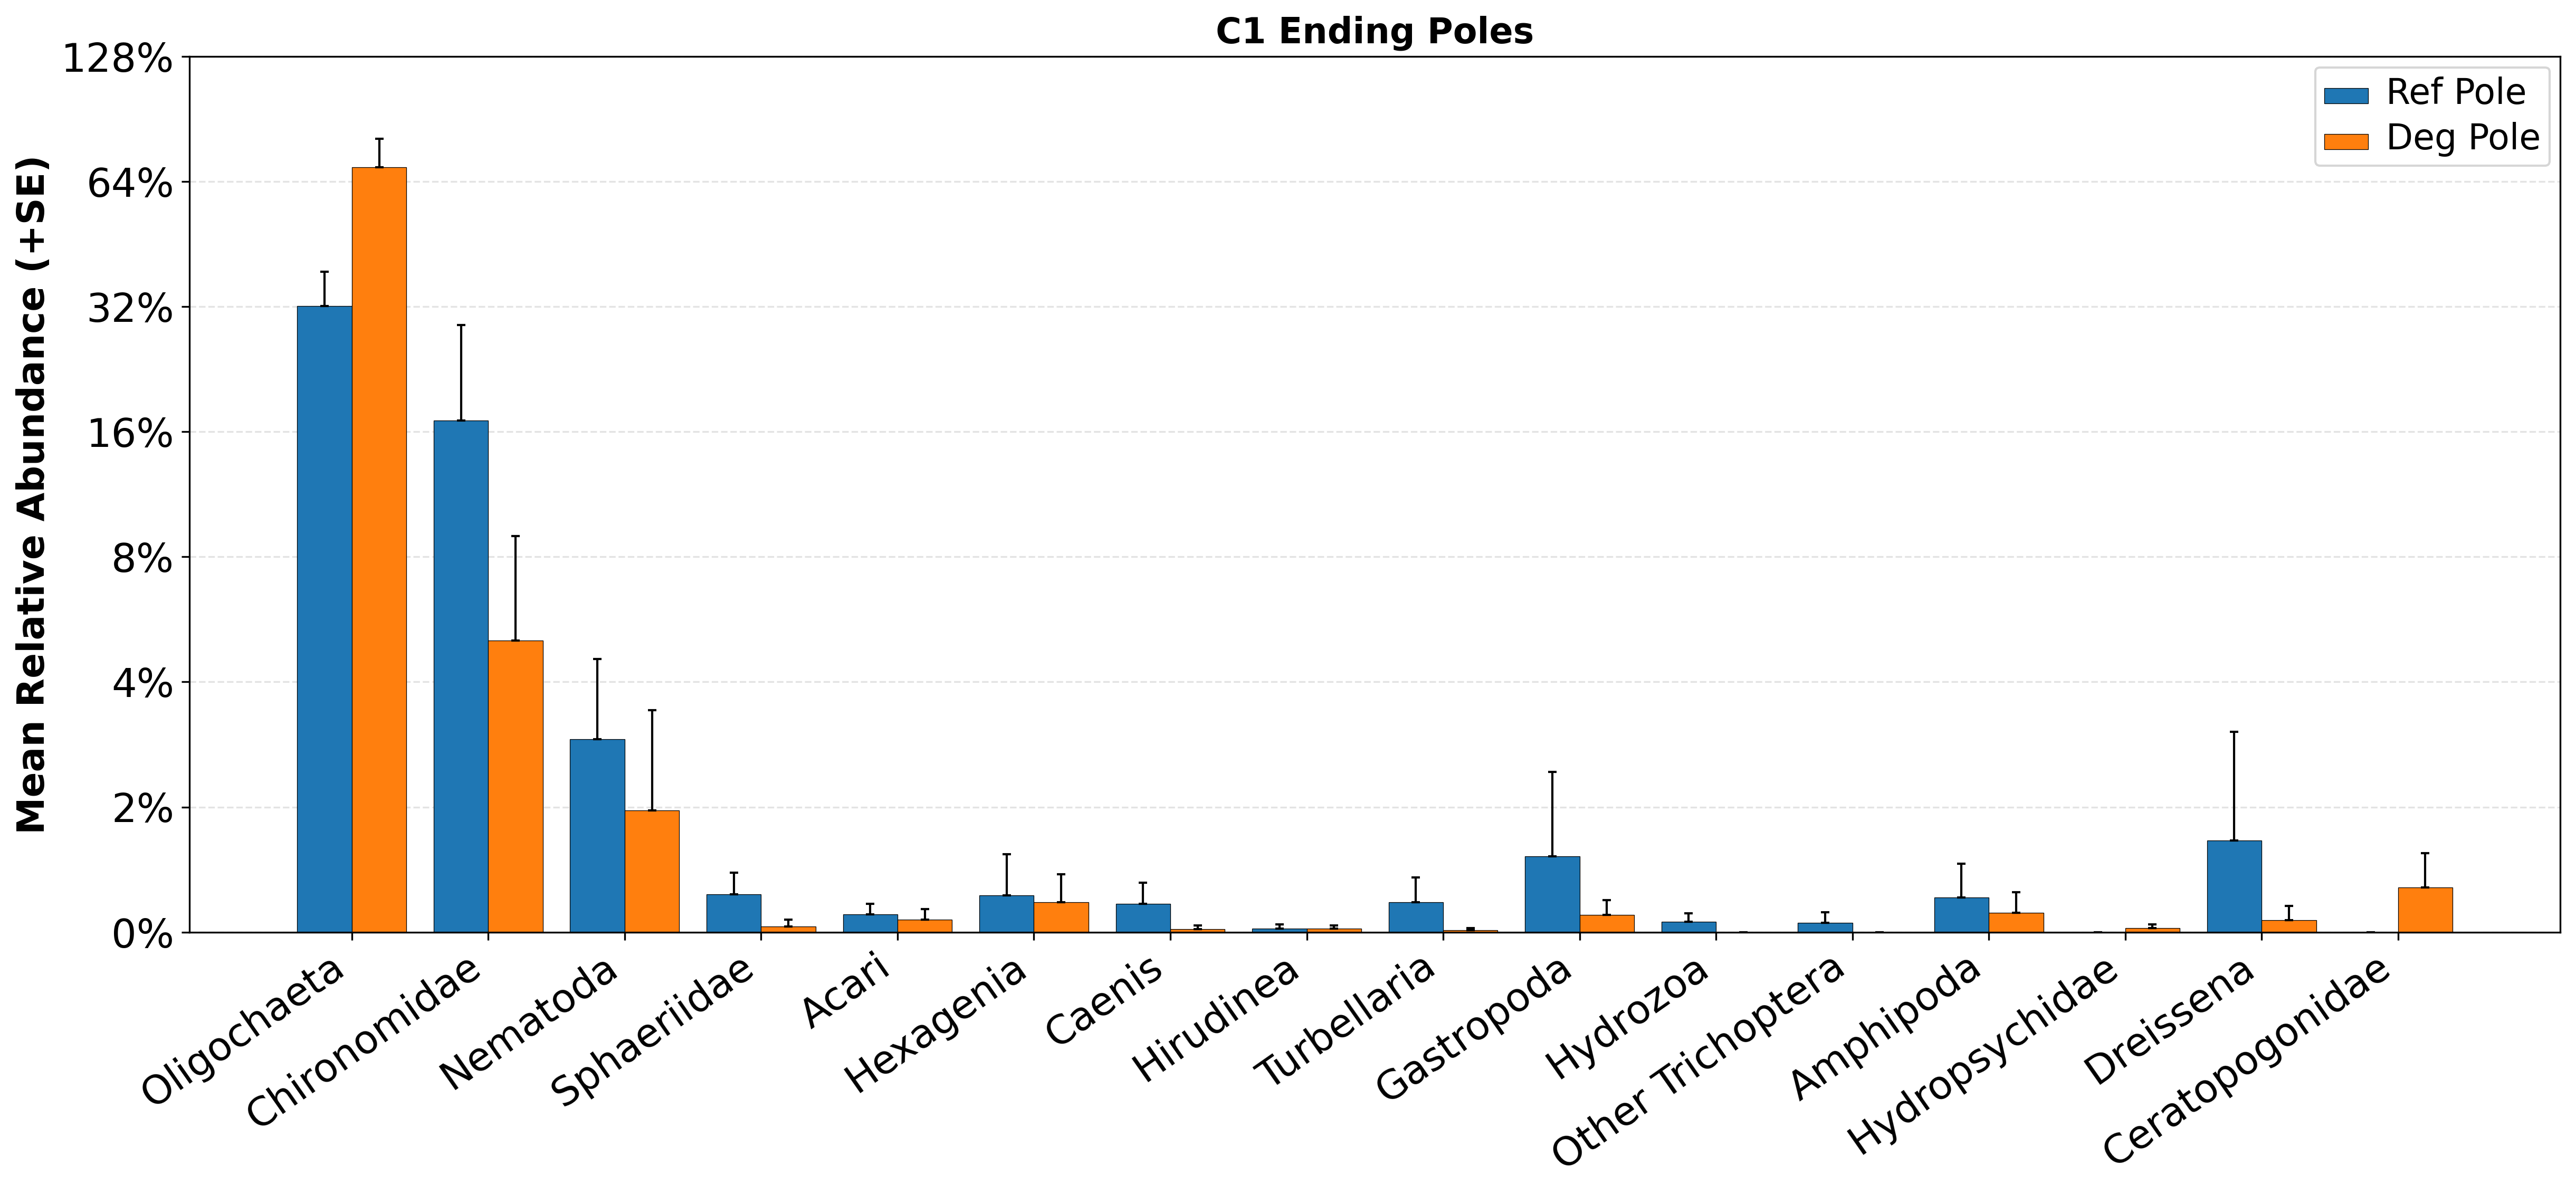

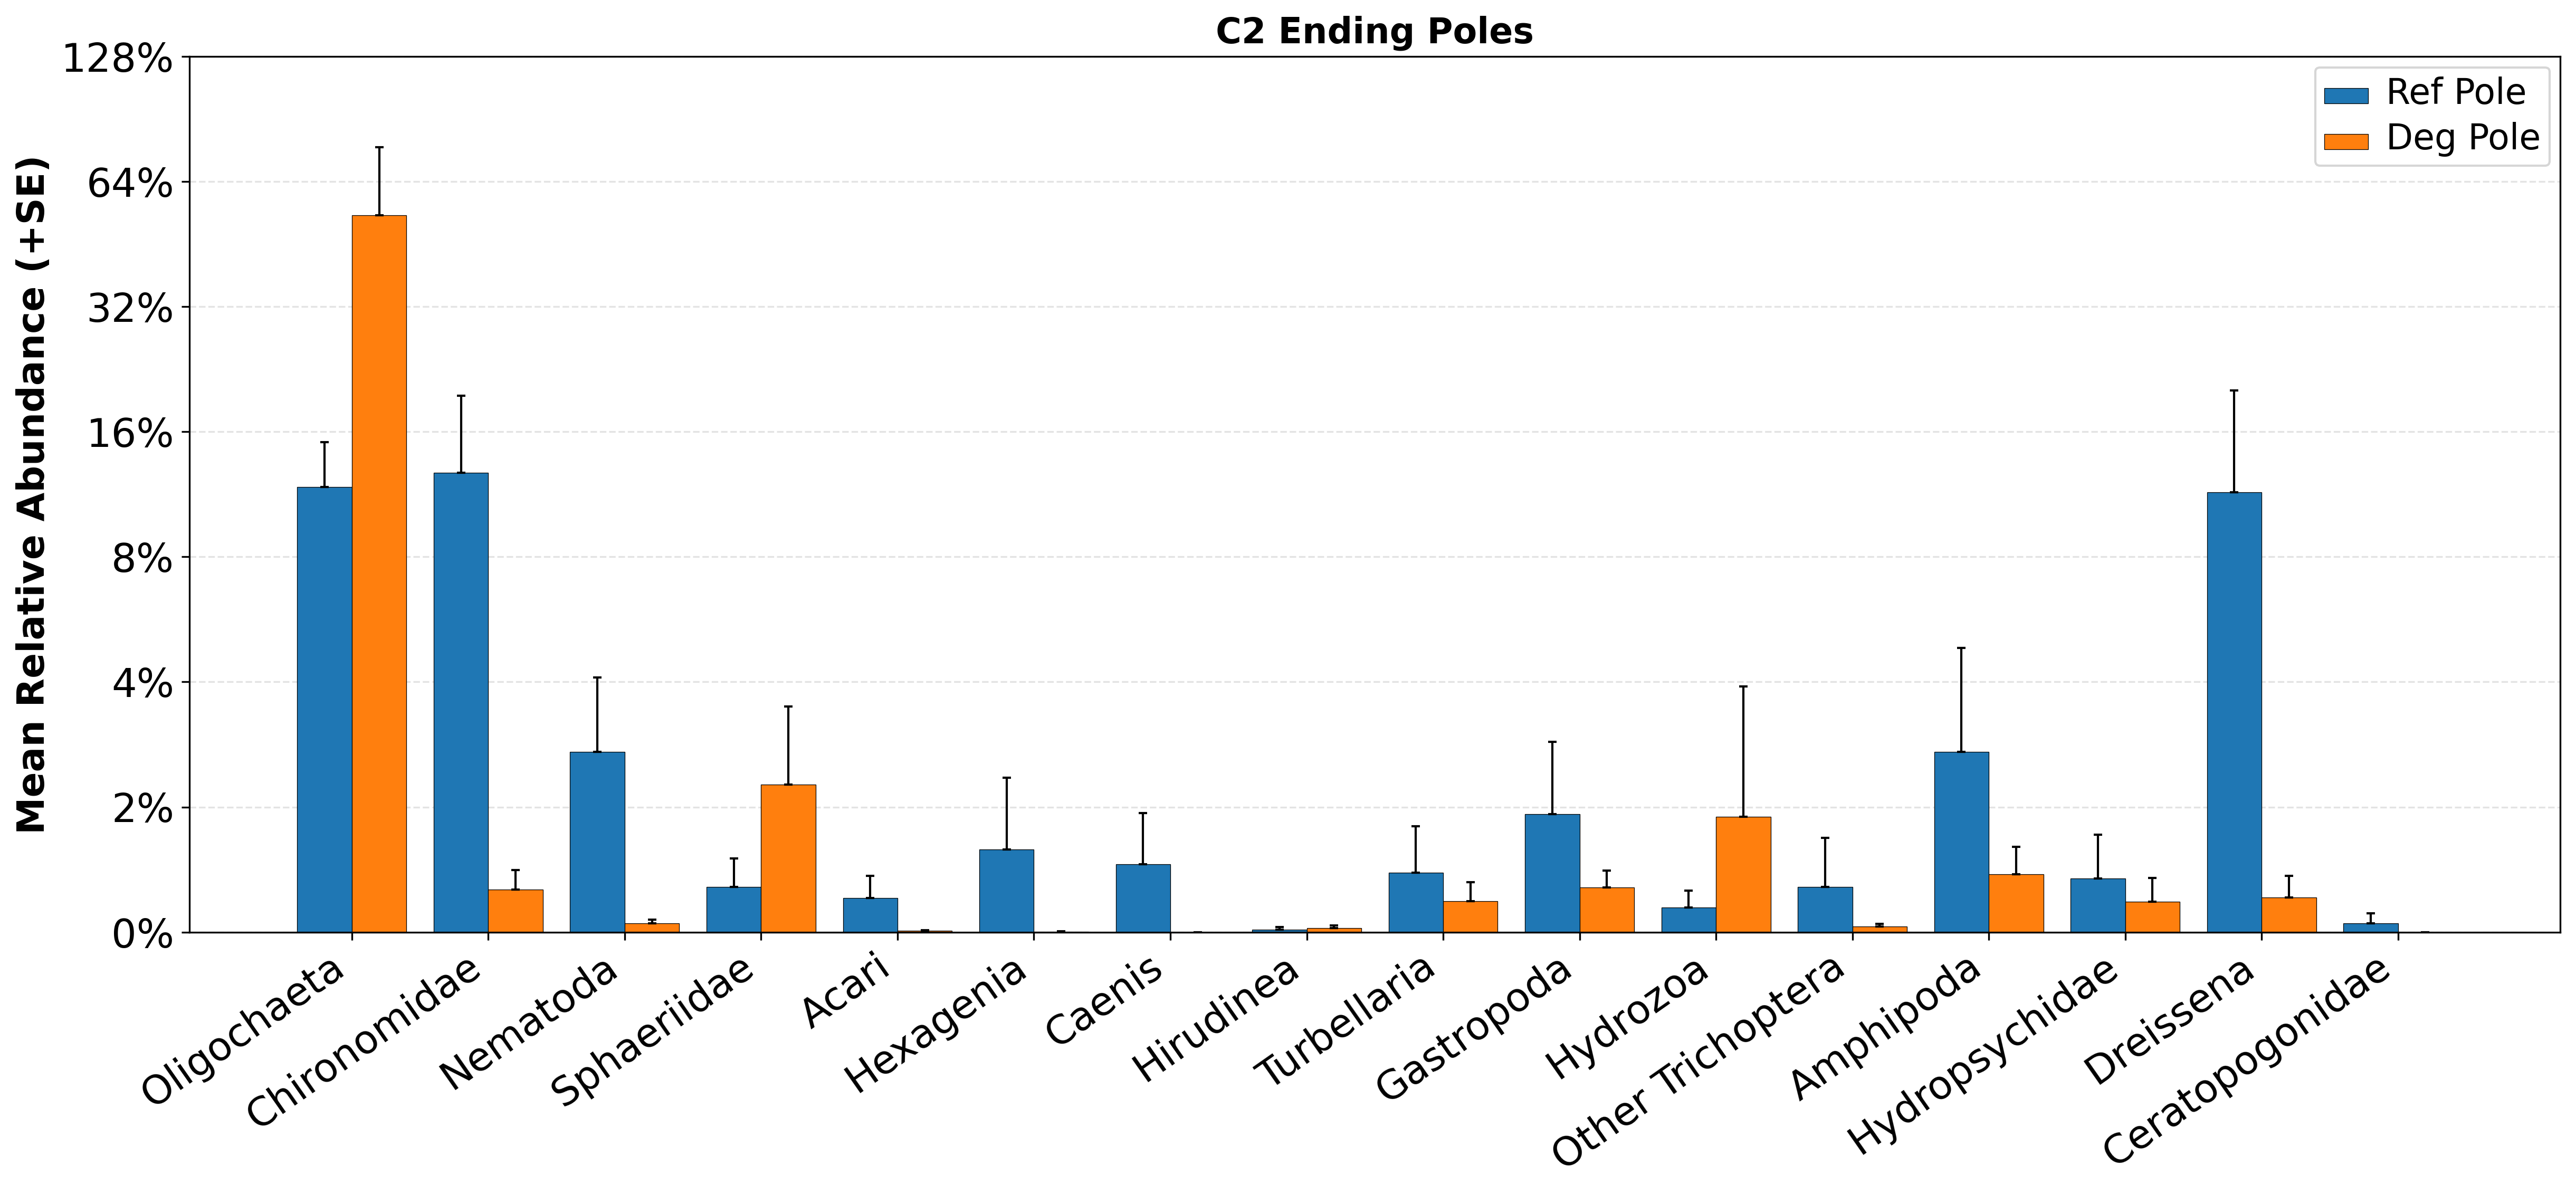

In [87]:
display(C1_barplot_figure)
plt.close(C1_barplot_figure)

display(C2_barplot_figure)
plt.close(C2_barplot_figure)

if STUDY_CASE == "DR":
    display(C3_barplot_figure)
    plt.close(C3_barplot_figure)


# Execution summary

After a complete corridor-case run, this notebook produces:

```text
../artifacts/A7_C1_bray_curtis_dissimilarity_matrix.xlsx
../artifacts/A8_C2_bray_curtis_dissimilarity_matrix.xlsx
```

When `STUDY_CASE = "DR"`, the same output filenames are written under:

```text
../DetroitRiverCase/results/
../DetroitRiverCase/artifacts/
../DetroitRiverCase/figures/
```